In [ ]:
from alerce.core import Alerce
import pandas as pd
import time
import threading
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
from tqdm import tqdm

# ===============================
# CONFIG
# ===============================
csv_file = "lsst_agn_alerce.csv"
output_csv = "coordinates_with_ids.csv"
search_radius_arcsec = 1.0
MAX_WORKERS = 10        # lower default — easier to diagnose stalls
SAVE_EVERY = 200
RETRY_ATTEMPTS = 3
RETRY_DELAY = 2
RESUME = True
REQUEST_TIMEOUT = 20    # FIX: seconds before a hung request is abandoned
STALL_TIMEOUT = 120     # FIX: if no progress for this many seconds, warn loudly

# ===============================
# THREAD-LOCAL CLIENTS
# ===============================
_thread_local = threading.local()

def get_client():
    if not hasattr(_thread_local, "client"):
        _thread_local.client = Alerce()
        # FIX: patch the underlying requests session with a timeout
        # so no single HTTP call can hang forever
        if hasattr(_thread_local.client, "session") and isinstance(_thread_local.client.session, requests.Session):
            original_get = _thread_local.client.session.get
            original_post = _thread_local.client.session.post
            _thread_local.client.session.get  = lambda *a, **kw: original_get(*a, timeout=kw.pop("timeout", REQUEST_TIMEOUT), **kw)
            _thread_local.client.session.post = lambda *a, **kw: original_post(*a, timeout=kw.pop("timeout", REQUEST_TIMEOUT), **kw)
    return _thread_local.client

# ===============================
# SHARED STATE
# ===============================
lock = Lock()
matched_rows = []
checkpoint_counter = 0
rate_limit_hits = 0
last_progress_time = time.time()   # FIX: stall detector

# ===============================
# LOAD COORDINATES
# ===============================
df = pd.read_csv(csv_file)
if "meanra" not in df.columns or "meandec" not in df.columns:
    raise ValueError("CSV must contain 'meanra' and 'meandec' columns")

df = df[df['meandec'] > -30].copy()
print(f"{len(df)} objects in ZTF footprint (dec > -30°)")

# ===============================
# RESUME
# ===============================
if RESUME:
    try:
        done_df = pd.read_csv(output_csv)
        done_keys = set(zip(done_df["meanra"].round(6), done_df["meandec"].round(6)))
        df["_key"] = list(zip(df["meanra"].round(6), df["meandec"].round(6)))
        df = df[~df["_key"].isin(done_keys)].drop(columns=["_key"])
        matched_rows = done_df.to_dict("records")
        print(f"Resuming: {len(done_df)} done, {len(df)} remaining.\n")
    except FileNotFoundError:
        print(f"Loaded {len(df)} coordinates. Starting fresh.\n")
else:
    print(f"Loaded {len(df)} coordinates. Starting with {MAX_WORKERS} workers...\n")

# ===============================
# QUERY FUNCTION
# ===============================
def query_row(args):
    index, row = args
    ra = row["meanra"]
    dec = row["meandec"]
    alerce = get_client()

    for attempt in range(RETRY_ATTEMPTS):
        try:
            objs = alerce.query_objects(
                survey="ztf",
                ra=ra,
                dec=dec,
                radius=search_radius_arcsec
            )
            if objs is not None and not objs.empty:
                oids = objs["oid"].tolist()
                row_data = row.to_dict()
                row_data["matched_oids"] = ",".join(oids)
                return row_data, ra, dec, oids
            else:
                return None, ra, dec, []

        except requests.exceptions.Timeout:
            # FIX: timeouts are now caught explicitly and not retried the same
            # way as other errors — they mean the server is slow/down, not that
            # we did something wrong
            tqdm.write(f"⏱  Timeout at RA={ra:.4f}, DEC={dec:.4f} (attempt {attempt+1})")
            if attempt < RETRY_ATTEMPTS - 1:
                time.sleep(RETRY_DELAY * (attempt + 1))
            else:
                return "timeout", ra, dec, None

        except Exception as e:
            err = str(e).lower()
            is_rate_limit = "429" in err or "rate limit" in err or "too many" in err
            if is_rate_limit:
                time.sleep(RETRY_DELAY * 5 * (attempt + 1))
                return "rate_limit", ra, dec, None
            elif attempt < RETRY_ATTEMPTS - 1:
                time.sleep(RETRY_DELAY * (attempt + 1))
            else:
                return "error", ra, dec, None

# ===============================
# STALL DETECTOR (background thread)
# ===============================
stall_warned = False

def stall_detector():
    global stall_warned
    while True:
        time.sleep(30)
        elapsed = time.time() - last_progress_time
        if elapsed > STALL_TIMEOUT:
            if not stall_warned:
                print(f"\n🚨 STALL DETECTED: No futures completed in {elapsed:.0f}s.")
                print(f"   All {MAX_WORKERS} workers are likely hung on requests.")
                print(f"   This usually means the API is unreachable or very slow.")
                print(f"   Consider: lowering MAX_WORKERS, checking API status, or restarting.")
                stall_warned = True
        else:
            stall_warned = False

detector = threading.Thread(target=stall_detector, daemon=True)
detector.start()

# ===============================
# PARALLEL EXECUTION
# ===============================
timeout_count = 0
error_count = 0
rate_limit_hits = 0
checkpoint_counter = 0
matched_rows = matched_rows or []  # in case RESUME populated it

def save_checkpoint(rows, path):
    if rows:
        pd.DataFrame(rows).to_csv(path, index=False)

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(query_row, (i, row)): i for i, row in df.iterrows()}

    with tqdm(total=len(futures), desc="Querying ALeRCE") as pbar:
        for future in as_completed(futures):
            try:
                res, ra, dec, oids = future.result()  # unpack safely
            except Exception as e:
                print("Error with a future:", e)
                res = ra = dec = oids = None

            with lock:
                last_progress_time = time.time()  # reset stall detector

                if res == "rate_limit":
                    rate_limit_hits += 1
                    if rate_limit_hits % 10 == 1:
                        tqdm.write(f"⚠️  Rate limit ({rate_limit_hits}x) — lower MAX_WORKERS if frequent")
                elif res == "timeout":
                    timeout_count += 1
                    if timeout_count % 20 == 1:
                        tqdm.write(f"⏱  Timeouts so far: {timeout_count} — API may be throttling or unstable")
                elif res == "error":
                    error_count += 1
                elif res is not None:
                    matched_rows.append(res)
                    tqdm.write(f"✅ RA={ra:.5f}, DEC={dec:.5f} -> {oids}")

                checkpoint_counter += 1
                if checkpoint_counter % SAVE_EVERY == 0:
                    save_checkpoint(matched_rows, output_csv)
                    tqdm.write(f"Checkpoint saved ({len(matched_rows)} matches so far)")

            pbar.update(1)
# ===============================
# FINAL SAVE + SUMMARY
# ===============================
if matched_rows:
    matched_df = pd.DataFrame(matched_rows)
    matched_df.to_csv(output_csv, index=False)
    print(f"\n✅ Done! {len(matched_rows)} matches saved to '{output_csv}'")
else:
    print("\nNo matches found.")

print(f"\nSummary:")
print(f"  Matches:      {len(matched_rows)}")
print(f"  Rate limits:  {rate_limit_hits}")
print(f"  Timeouts:     {timeout_count}")
print(f"  Other errors: {error_count}")

18046 objects in ZTF footprint (dec > -30°)
Resuming: 457 done, 17720 remaining.



Querying ALeRCE:   0%|          | 32/17720 [00:02<19:22, 15.21it/s] 


In [ ]:
from alerce.core import Alerce
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
from tqdm import tqdm


csv_file = "lsst_agn_rubin.csv"
output_csv = "coordinates_with_ids.csv"
search_radius_arcsec = 1.0
MAX_WORKERS = 15
SAVE_EVERY = 500
RETRY_ATTEMPTS = 3
RETRY_DELAY = 2
RESUME = True


_thread_local_clients = {}
_client_lock = Lock()

def get_client():
    tid = id(Lock())  # use thread id via a simple trick
    import threading
    tid = threading.get_ident()
    if tid not in _thread_local_clients:
        with _client_lock:
            if tid not in _thread_local_clients:
                _thread_local_clients[tid] = Alerce()
    return _thread_local_clients[tid]

lock = Lock()
matched_rows = []
checkpoint_counter = 0
rate_limit_hits = 0

df = pd.read_csv(csv_file)
if "meanra" not in df.columns or "meandec" not in df.columns:
    raise ValueError("CSV must contain 'meanra' and 'meandec' columns")

df = df[df['meandec'] > -30].copy()
print(f"{len(df)} objects in ZTF footprint (dec > -30°)")


if RESUME:
    try:
        done_df = pd.read_csv(output_csv)
        # BUG FIX 2: Original used a slow per-row lambda + set lookup.
        # Build a set of tuples and use merge-based filtering instead — 
        # ~100x faster on large DataFrames.
        done_keys = set(zip(done_df["meanra"].round(6), done_df["meandec"].round(6)))
        df["_key"] = list(zip(df["meanra"].round(6), df["meandec"].round(6)))
        df = df[~df["_key"].isin(done_keys)].drop(columns=["_key"])
        matched_rows = done_df.to_dict("records")
        print(f"Resuming: {len(done_df)} done, {len(df)} remaining.\n")
    except FileNotFoundError:
        print(f"Loaded {len(df)} coordinates. Starting fresh.\n")
else:
    print(f"Loaded {len(df)} coordinates. Starting with {MAX_WORKERS} workers...\n")

def query_row(args):
    index, row = args
    ra = row["meanra"]
    dec = row["meandec"]
    alerce = get_client()

    for attempt in range(RETRY_ATTEMPTS):
        try:
            objs = alerce.query_objects(
                survey="ztf",
                ra=ra,
                dec=dec,
                radius=search_radius_arcsec,
                target_class = "AGN"
            )
            if objs is not None and not objs.empty:
                oids = objs["oid"].tolist()
                row_data = row.to_dict()
                row_data["matched_oids"] = ",".join(oids)
                return row_data, ra, dec, oids
            else:
                return None, ra, dec, []

        except Exception as e:
            err = str(e).lower()
            is_rate_limit = "429" in err or "rate limit" in err or "too many" in err
            if is_rate_limit:
                time.sleep(RETRY_DELAY * 5 * (attempt + 1))
                return "rate_limit", ra, dec, None
            elif attempt < RETRY_ATTEMPTS - 1:
                time.sleep(RETRY_DELAY * (attempt + 1))
            else:
                return None, ra, dec, None

def save_checkpoint(rows, path):
    if rows:
        pd.DataFrame(rows).to_csv(path, index=False)

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(query_row, (i, row)): i for i, row in df.iterrows()}

    with tqdm(total=len(df), desc="Querying ALeRCE") as pbar:
        for future in as_completed(futures):
            result, ra, dec, oids = future.result()

            with lock:
                if result == "rate_limit":
                    rate_limit_hits += 1
                    if rate_limit_hits % 10 == 1:
                        tqdm.write(f"⚠️  Rate limit ({rate_limit_hits}x) — lower MAX_WORKERS if frequent")
                elif result is not None:
                    matched_rows.append(result)
                    tqdm.write(f"✅ RA={ra:.5f}, DEC={dec:.5f} -> {oids}")

                checkpoint_counter += 1
                if checkpoint_counter % SAVE_EVERY == 0:
                    save_checkpoint(matched_rows, output_csv)
                    tqdm.write(f"Checkpoint saved ({len(matched_rows)} matches so far)")

            pbar.update(1)  # BUG FIX 3 cont: moved inside loop, outside lock


if matched_rows:
    matched_df = pd.DataFrame(matched_rows)
    matched_df.to_csv(output_csv, index=False)
    print(f"\n✅ Done! {len(matched_rows)} matches saved to '{output_csv}'")
    if rate_limit_hits:
        print(f"⚠️  Rate limits hit {rate_limit_hits}x — lower MAX_WORKERS next run")
else:
    print("\nNo matches found.")

32032 objects in ZTF footprint (dec > -30°)
Resuming: 519 done, 31514 remaining.



Querying ALeRCE:   2%|▏         | 501/31514 [00:20<20:15, 25.51it/s]

Checkpoint saved (519 matches so far)


Querying ALeRCE:   3%|▎         | 1007/31514 [00:40<17:12, 29.54it/s]

Checkpoint saved (519 matches so far)


Querying ALeRCE:   5%|▍         | 1499/31514 [03:52<2:50:59,  2.93it/s]

Checkpoint saved (519 matches so far)


Querying ALeRCE:   6%|▌         | 1755/31514 [05:36<1:35:13,  5.21it/s]


[1/27] Plotting 170050543269445727 / ZTF25aajvqcr


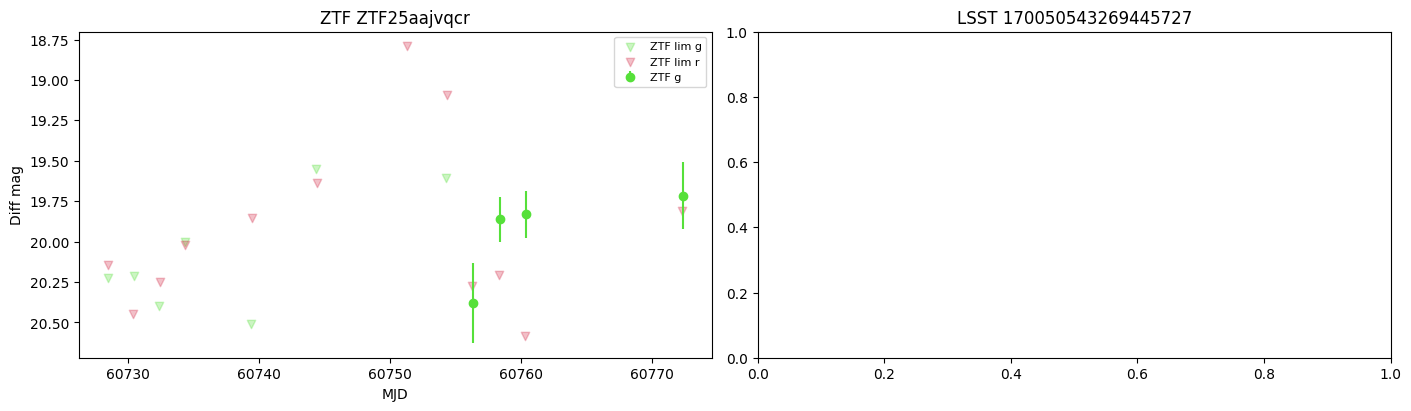

[2/27] Plotting 313980947939197053 / ZTF25accncco


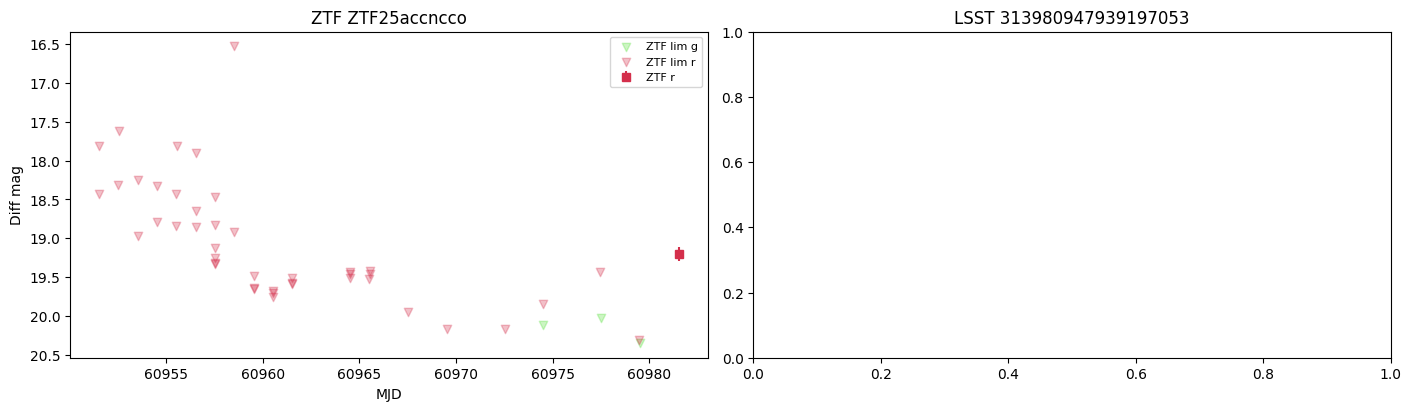

[3/27] Plotting 170028500560904312 / ZTF25aaqiiwr


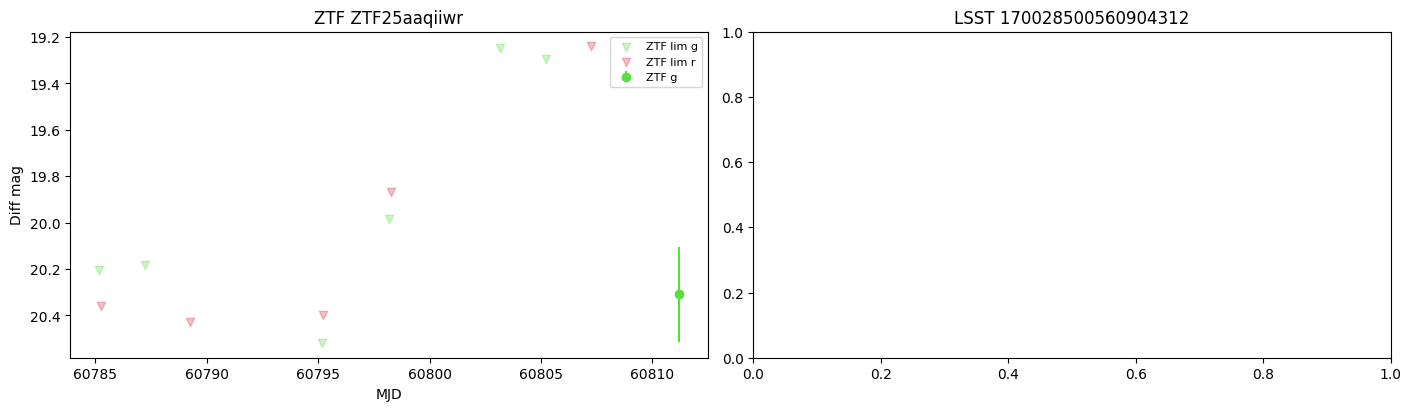

[4/27] Plotting 170028500601274484 / ZTF25aadwirt


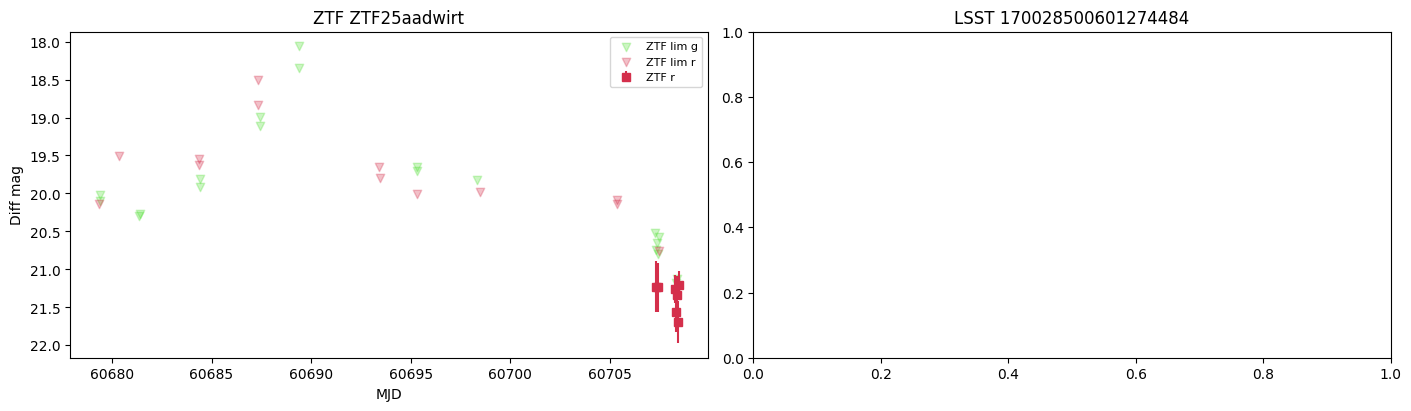

[5/27] Plotting 170028526787362939 / ZTF24aaiytvc


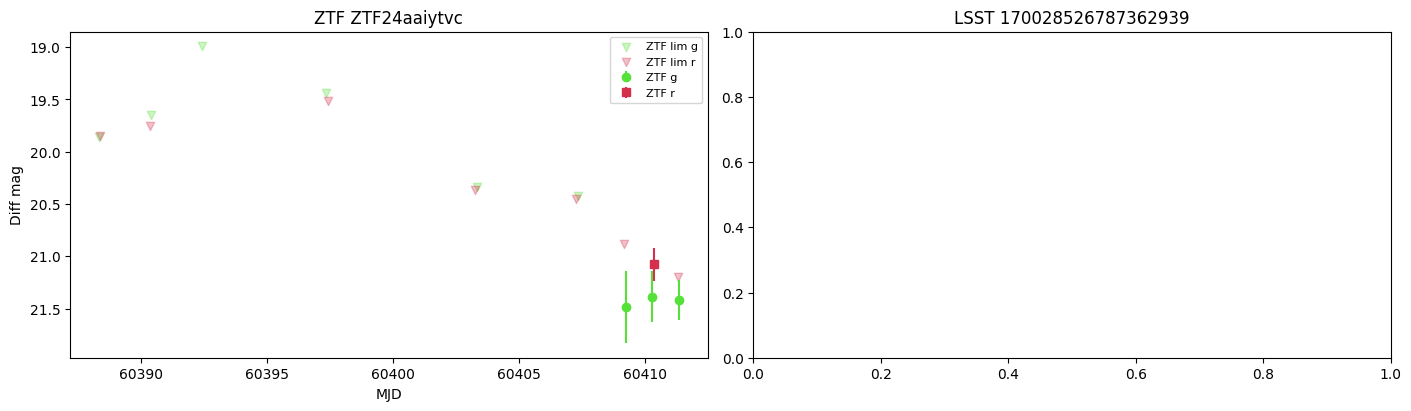

[6/27] Plotting 170028529201184903 / ZTF25aaqkvux


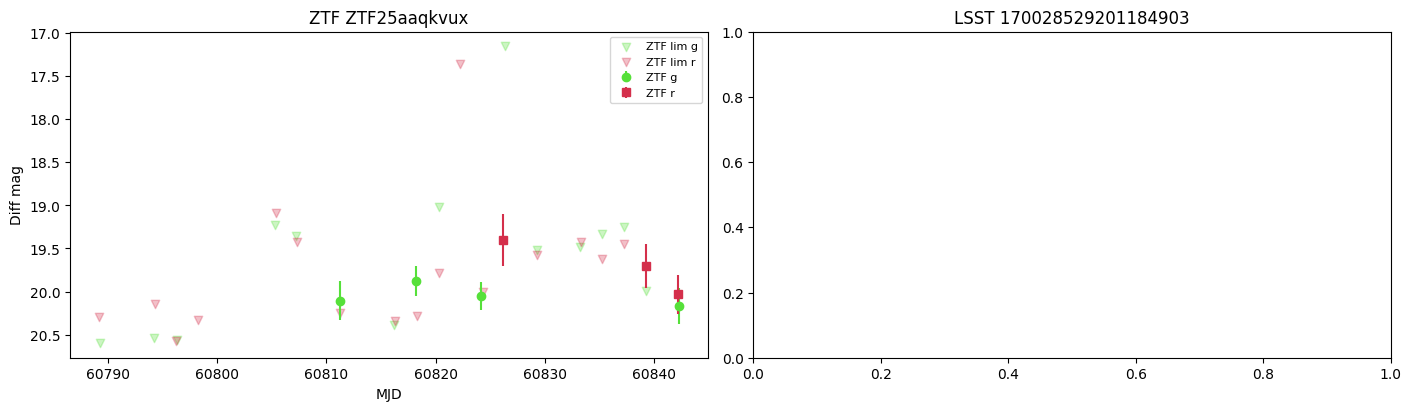

[7/27] Plotting 170028528011051109 / ZTF19aarnjya


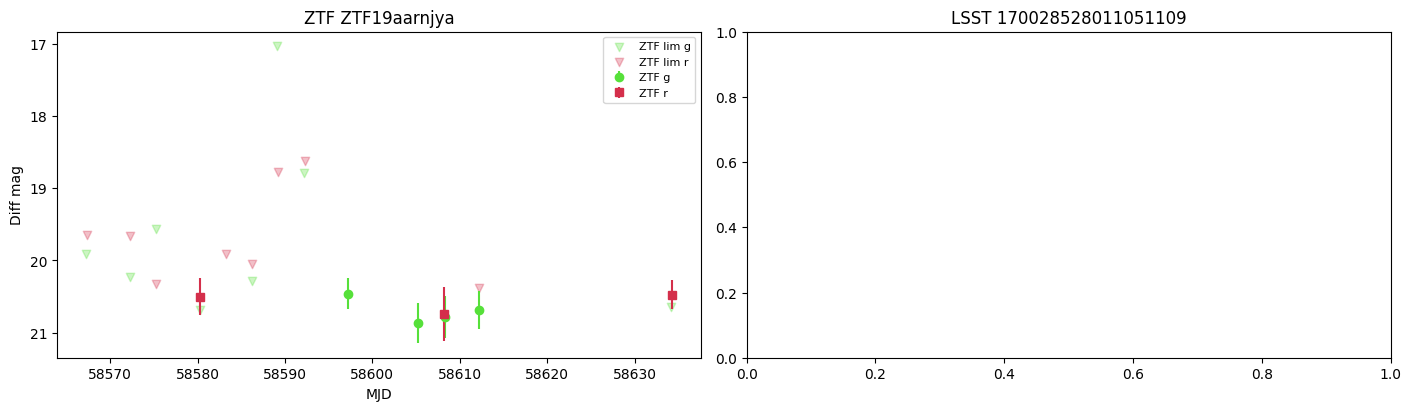

[8/27] Plotting 313853517960839281 / ZTF25aadzhwj


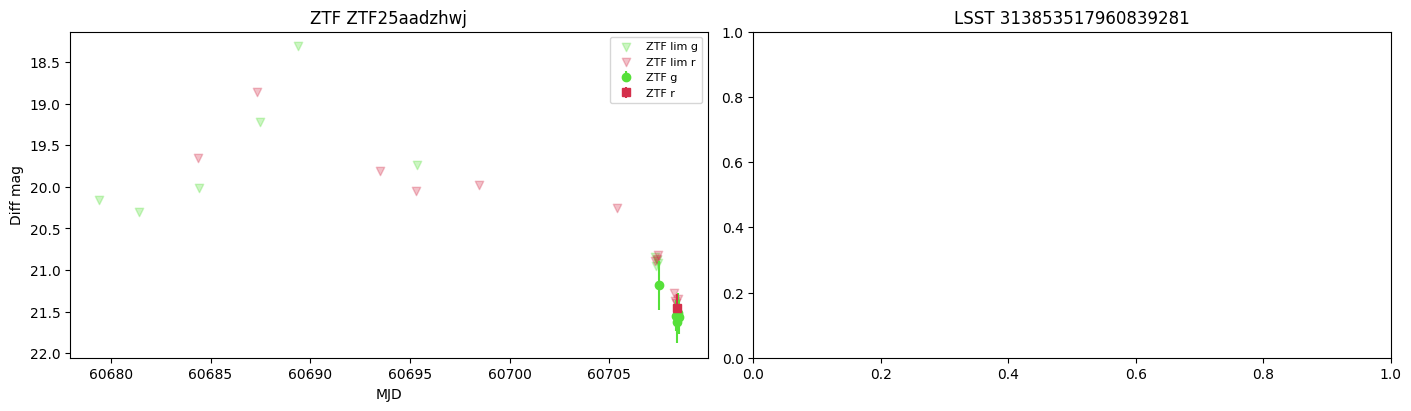

[9/27] Plotting 170028526514733131 / ZTF25aaqiujt


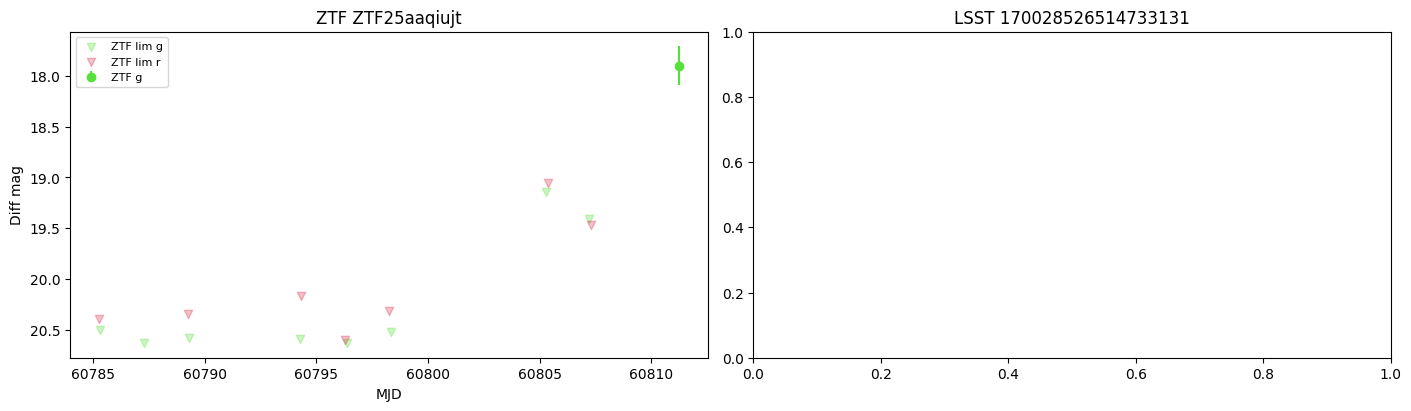

[10/27] Plotting 170028526517354588 / ZTF26aadnzgn


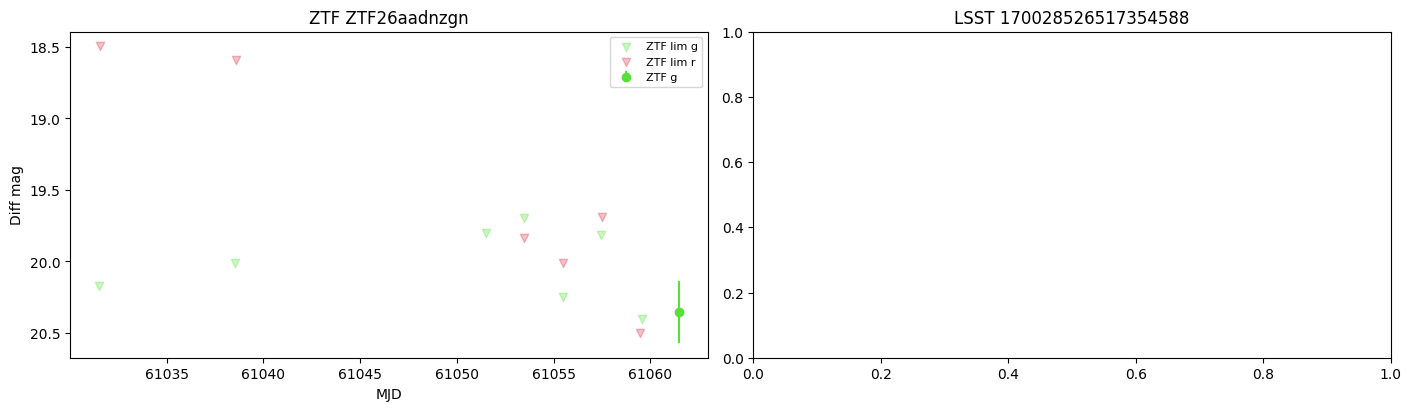

[11/27] Plotting 313871013105893607 / ZTF22aacqzpu


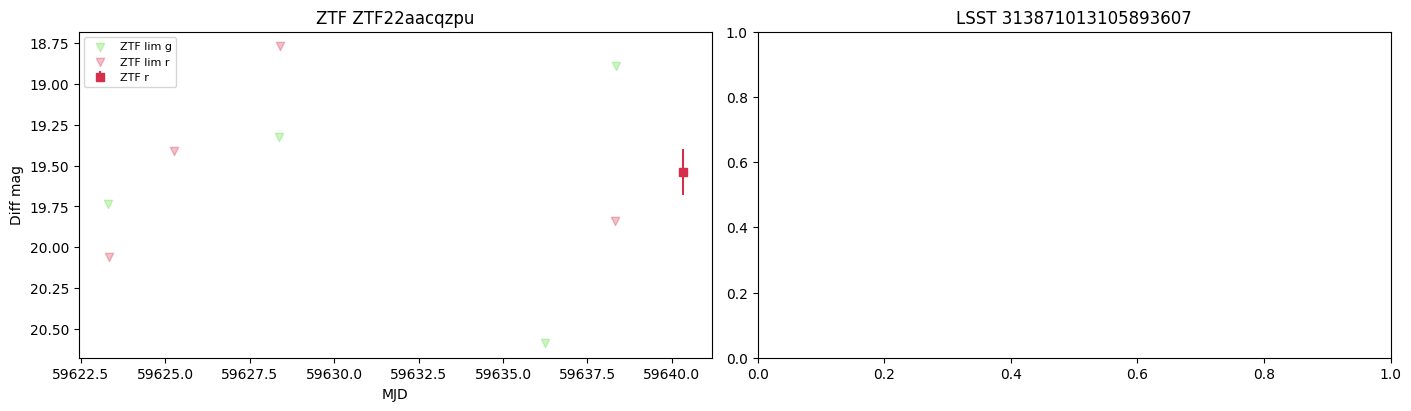

[12/27] Plotting 170028526620115087 / ZTF24aaiycse


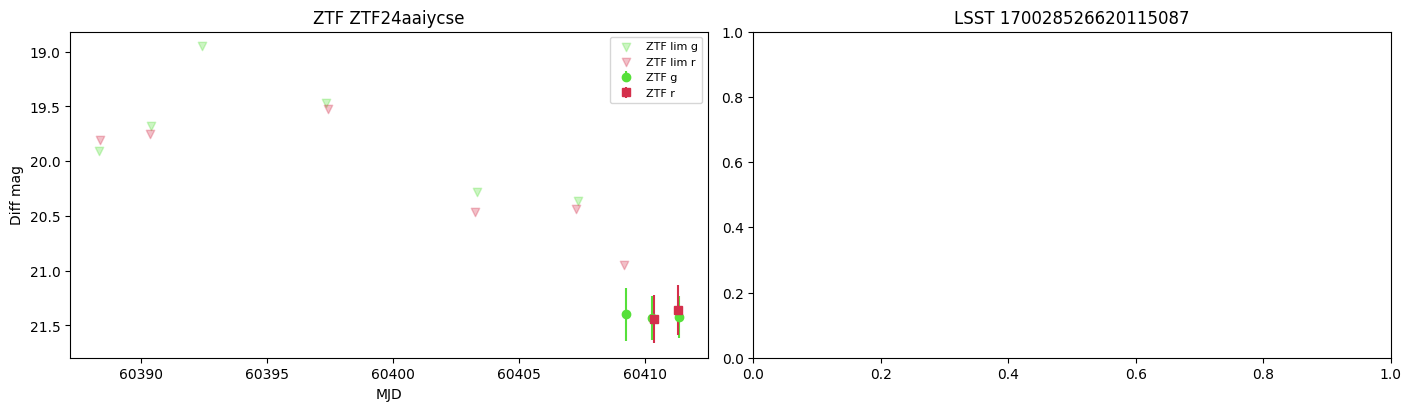

[13/27] Plotting 313963404992184401 / ZTF21aafjmdk


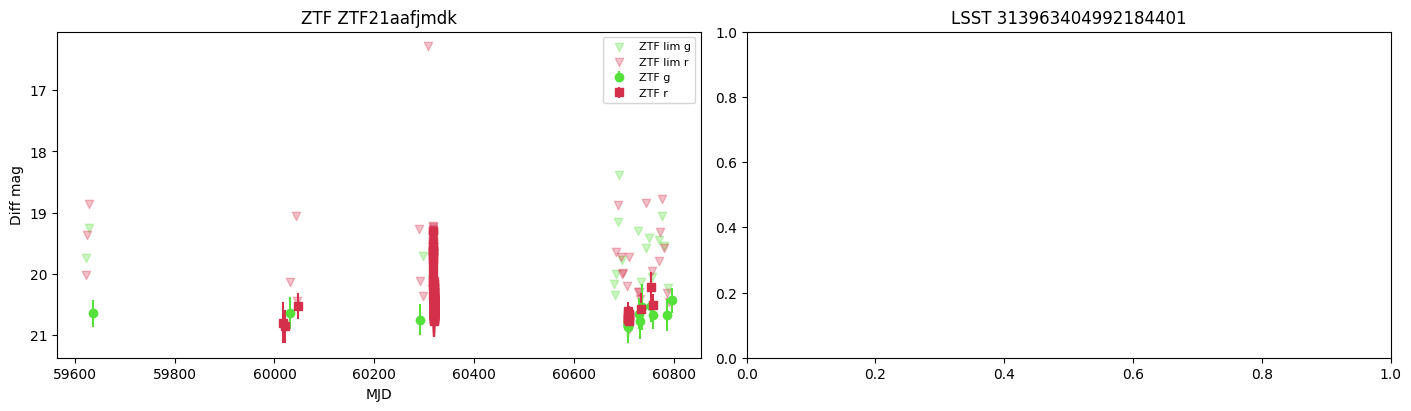

[14/27] Plotting 170028526534131828 / ZTF24aajcrfl


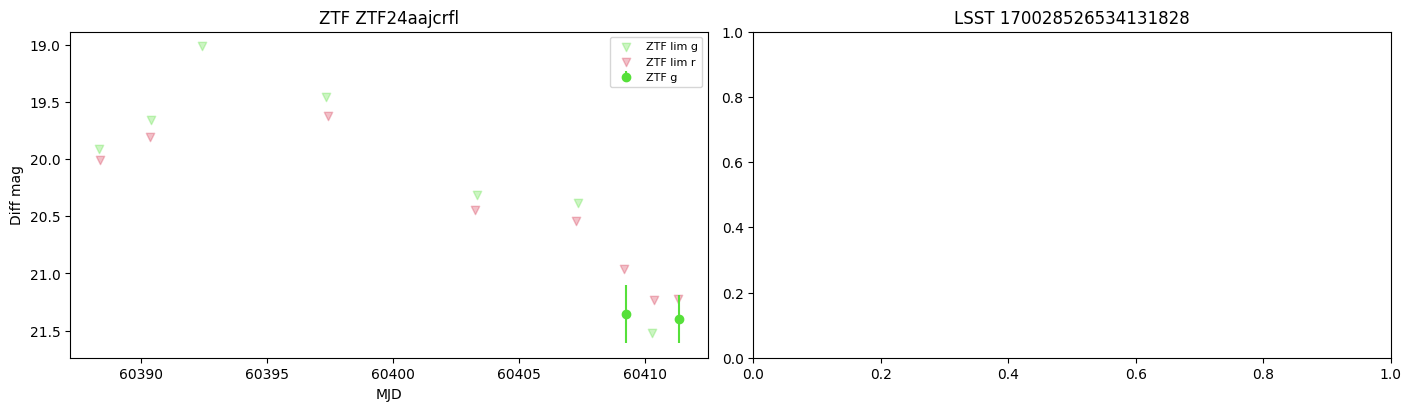

[15/27] Plotting 170028527973302368 / ZTF21acpgvtf


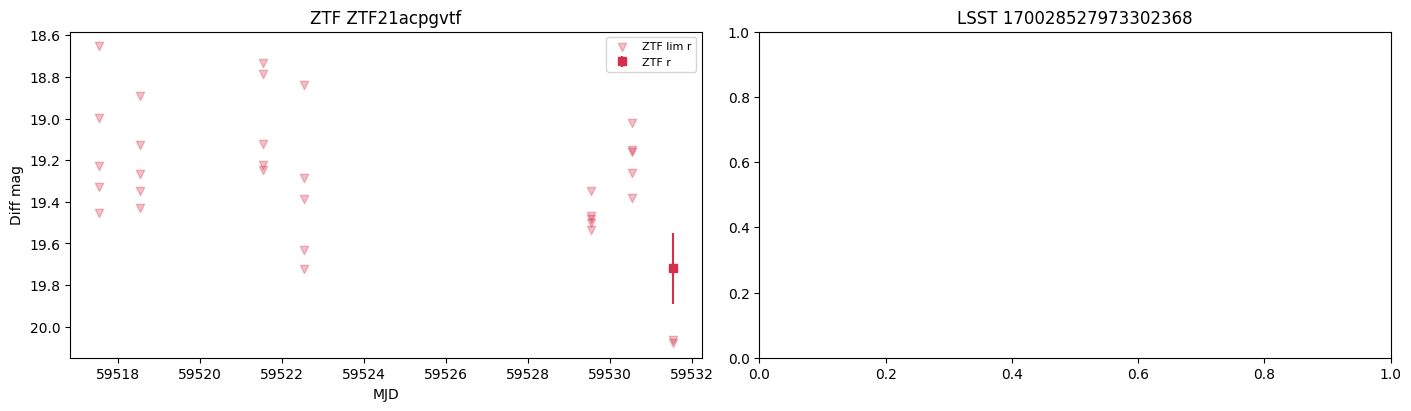

[16/27] Plotting 313875416840929413 / ZTF25aaebmsf


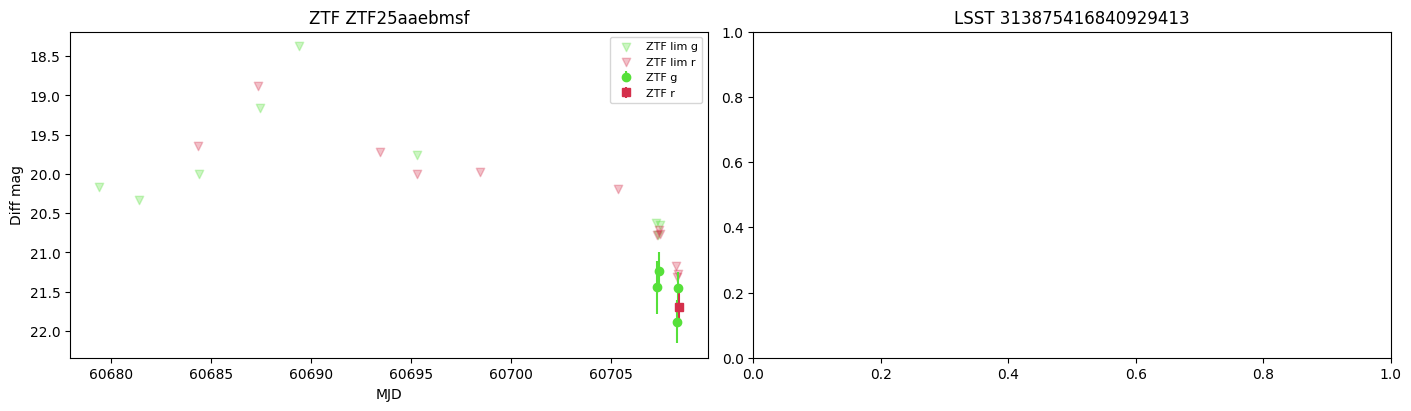

[17/27] Plotting 170050543269445740 / ZTF21aautxqr


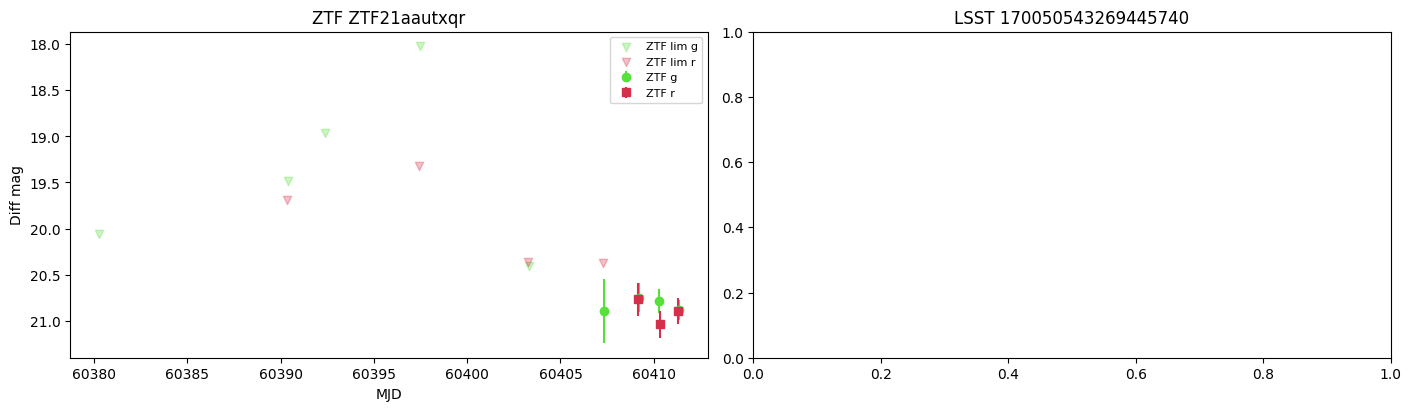

[18/27] Plotting 170028529317052506 / ZTF24aaqaroi


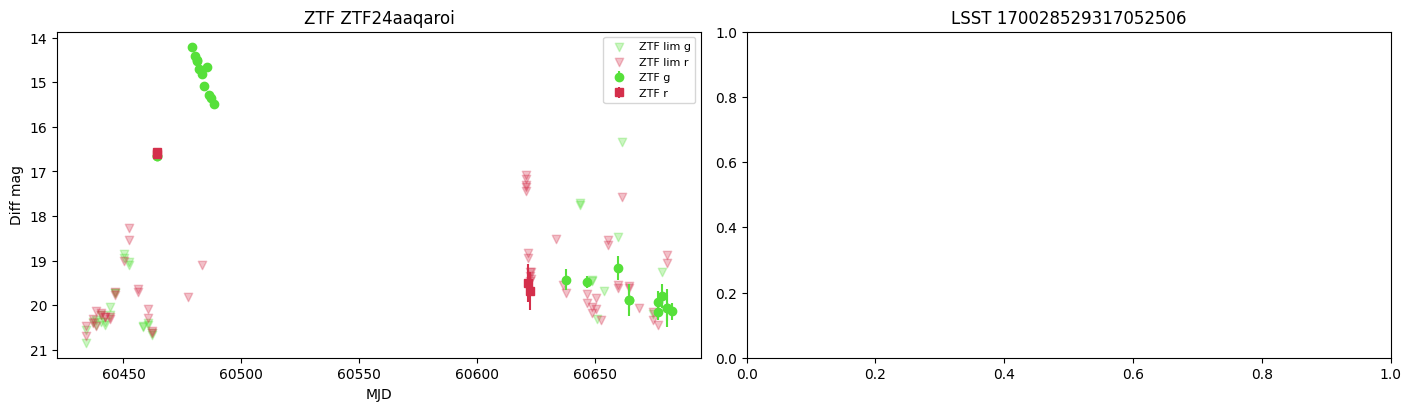

[19/27] Plotting 170028526449197298 / ZTF24aajckgi


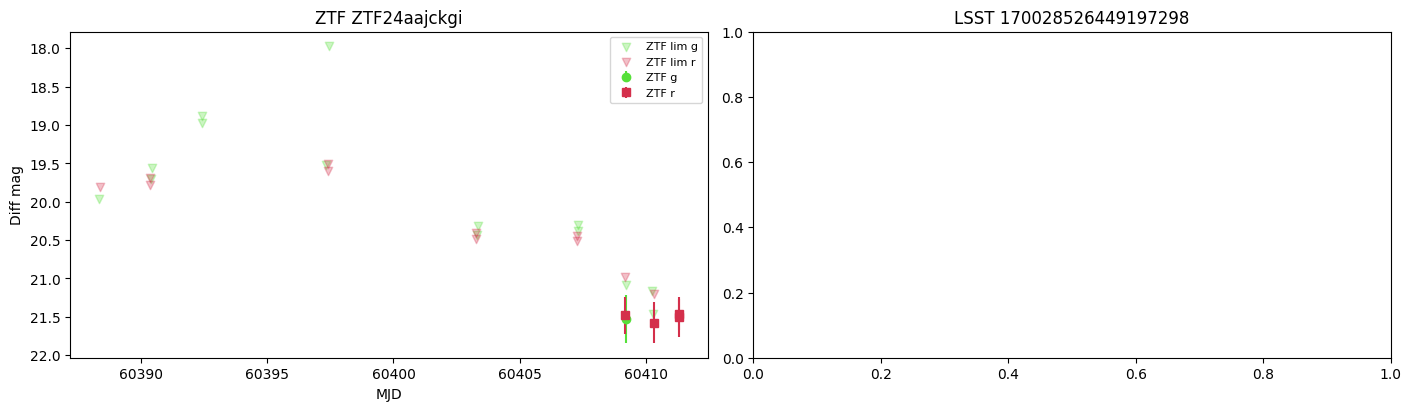

[20/27] Plotting 170028526465974408 / ZTF21aapqylb


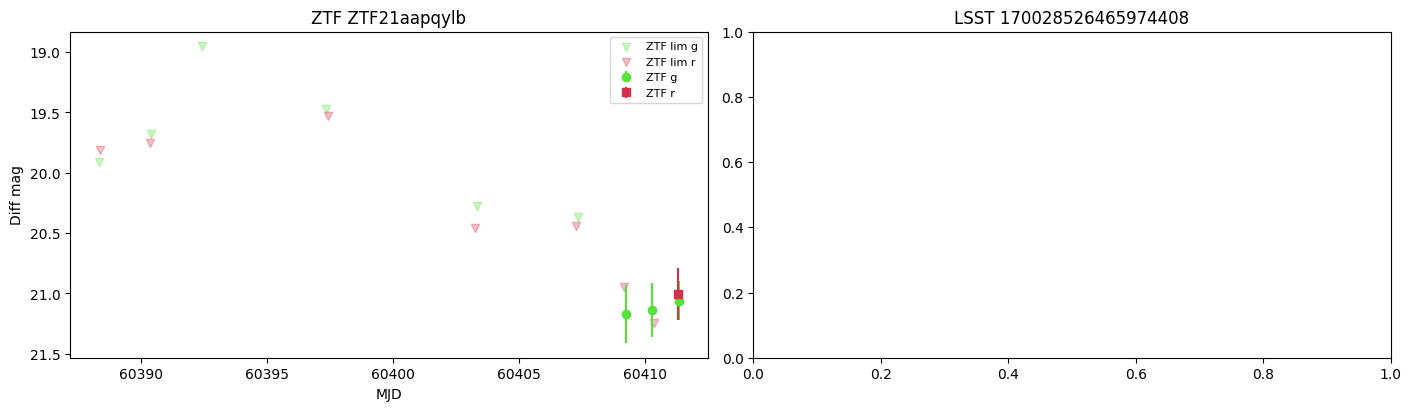

[21/27] Plotting 170050543265775719 / ZTF23aanddwt


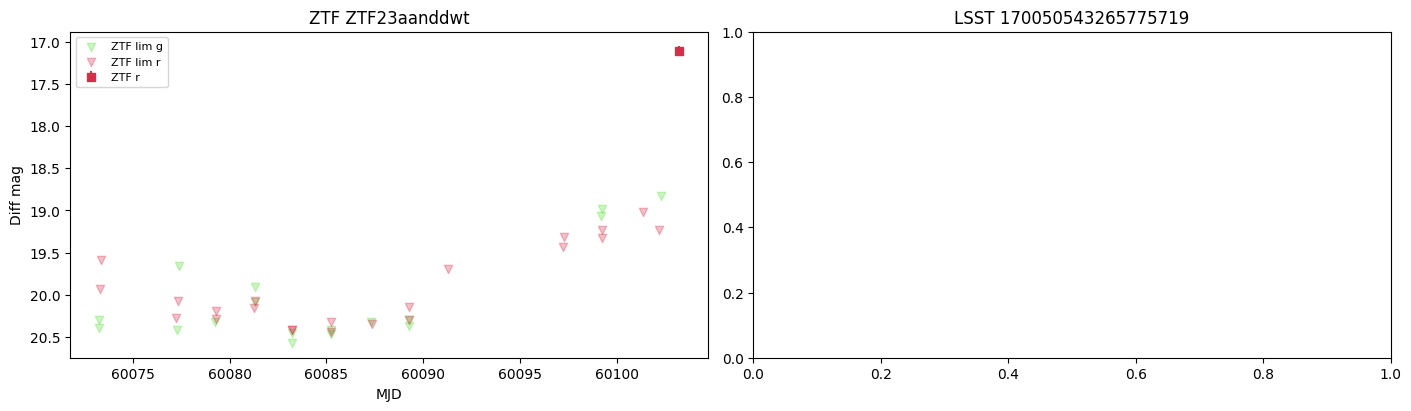

[22/27] Plotting 170028510637195392 / ZTF25aadwhpi


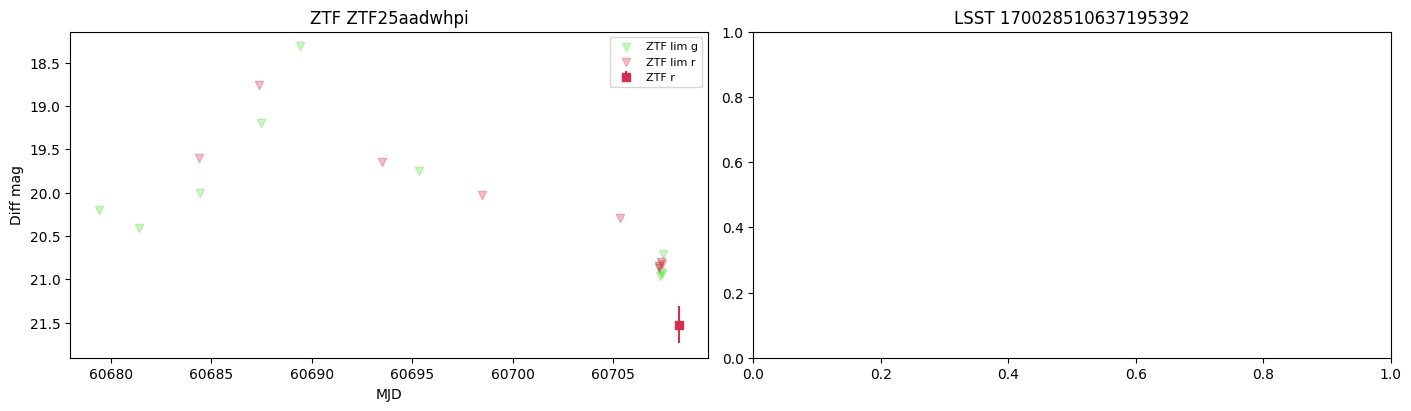

[23/27] Plotting 170032911737683987 / ZTF18acrmlwp


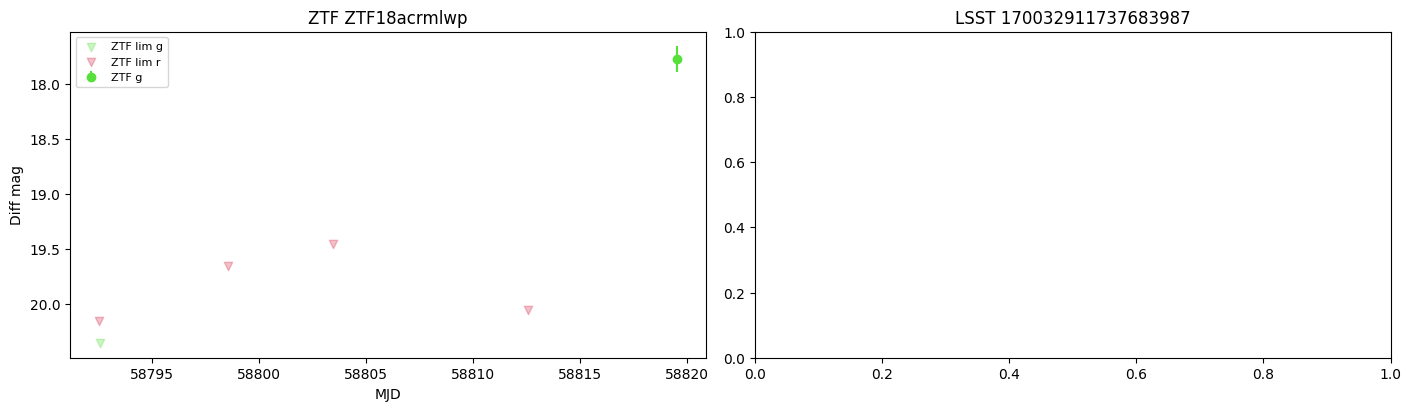

[24/27] Plotting 170050543252668544 / ZTF24aajcuof


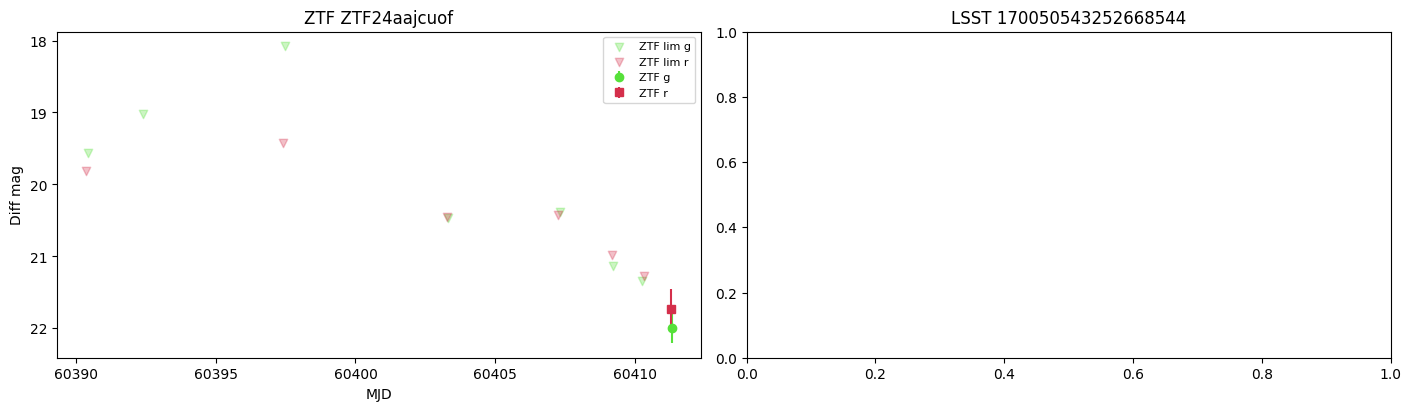

[25/27] Plotting 170028532667252850 / ZTF18aatuwys,ZTF18acvgvjj
⚠ ZTF fetch failed for ZTF18aatuwys,ZTF18acvgvjj: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}


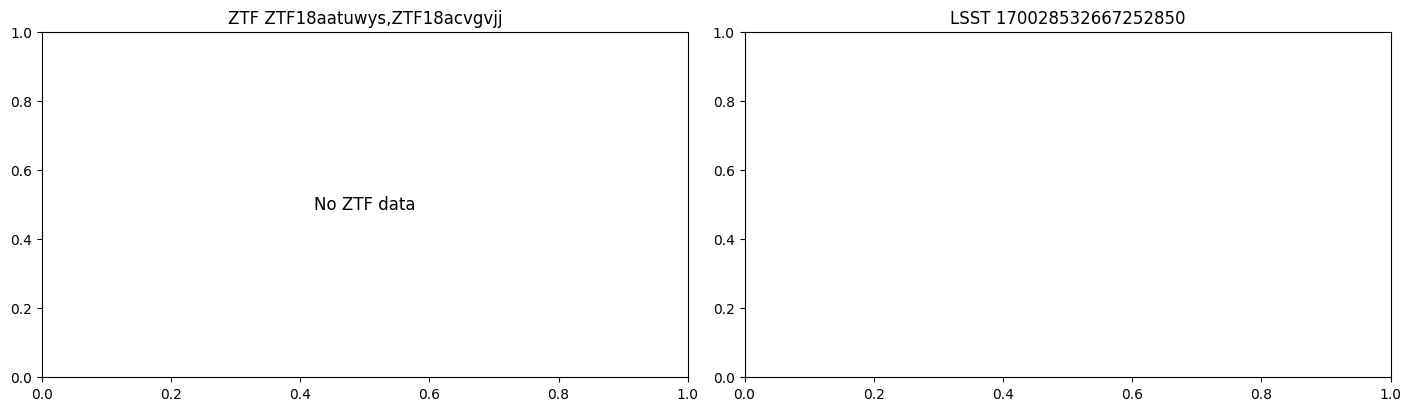

[26/27] Plotting 170028526498480272 / ZTF23aaowpre


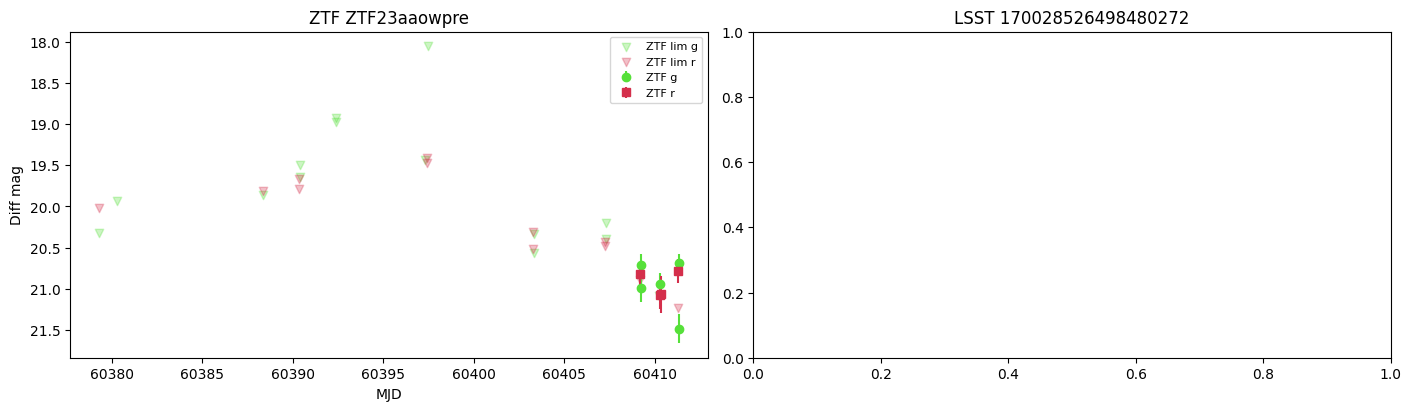

[27/27] Plotting 170050533266555213 / ZTF24aajcuok


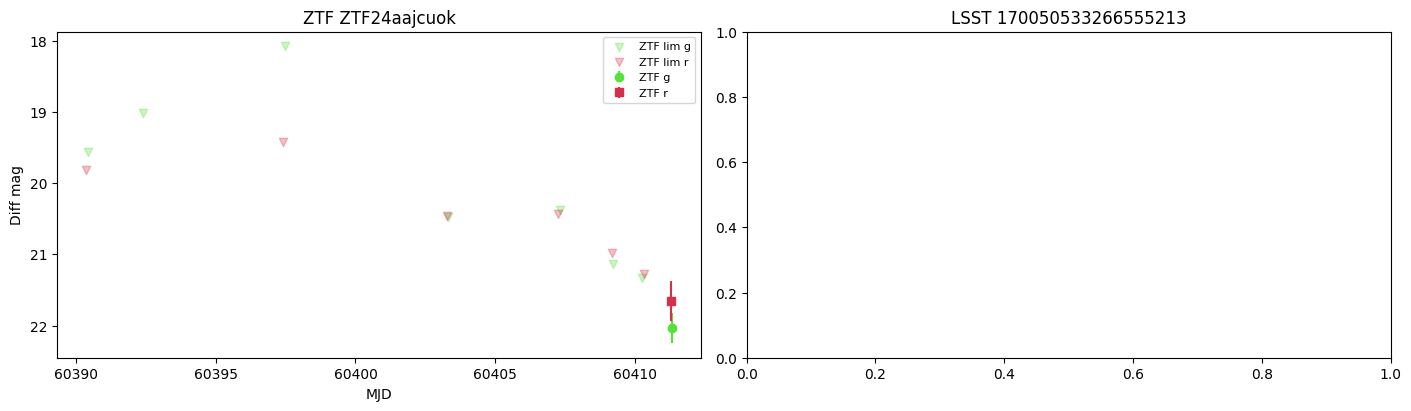


✓ All objects plotted successfully.


In [2]:
"""
safe_lsst_ztf_plot_fixed_ylim.py
--------------------------------
Batch plot LSST (detections + optional forced photometry) and ZTF
light curves side-by-side from a CSV. Handles missing data and
sets LSST magnitude axis 15–30 while keeping ZTF autoscaled.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alerce.core import Alerce

# ── CONFIG ──────────────────────────────────────────────
CSV_FILE = "coordinates_with_ids.csv"
USE_FLUX = False  # True = flux, False = magnitude

LSST_COLORS = {"u": "#1f77b4", "g": "#2ca02c", "r": "#d62728",
               "i": "#9467bd", "z": "#8c564b", "y": "#e377c2"}
ZTF_LABELS  = {1: 'g', 2: 'r'}
ZTF_COLORS  = {1: '#56E03A', 2: '#D42F4B'}
ZTF_MARKERS = {1: 'o', 2: 's'}
LSST_ZP = 31.4  # nJy zero-point

alerce_client = Alerce()

# ── HELPER FUNCTIONS ─────────────────────────────────────

def flux_to_mag(flux, flux_err, zp=LSST_ZP):
    flux = np.asarray(flux, dtype=float)
    flux_err = np.asarray(flux_err, dtype=float)
    mag = np.full_like(flux, np.nan)
    mag_err = np.full_like(flux, np.nan)
    good = flux > 0
    mag[good] = zp - 2.5 * np.log10(flux[good])
    mag_err[good] = (2.5 / np.log(10)) * (flux_err[good] / flux[good])
    return mag, mag_err

def fetch_lsst_safe(oid: int):
    try:
        df_dets = alerce_client.query_detections(oid, survey="lsst", format="pandas")
        df_forced = alerce_client.query_forced_photometry(oid, survey="lsst", format="pandas")
    except Exception as e:
        print(f"⚠ LSST fetch failed for {oid}: {e}")
        return pd.DataFrame(), pd.DataFrame()
    df_dets = df_dets if isinstance(df_dets, pd.DataFrame) else pd.DataFrame()
    df_forced = df_forced if isinstance(df_forced, pd.DataFrame) else pd.DataFrame()
    return df_dets, df_forced

def fetch_ztf_safe(matched_oids: str):
    try:
        LC_det = alerce_client.query_detections(matched_oids, format="pandas")
        LC_nondet = alerce_client.query_non_detections(matched_oids, format="pandas")
    except Exception as e:
        print(f"⚠ ZTF fetch failed for {matched_oids}: {e}")
        return pd.DataFrame(), pd.DataFrame()
    LC_det = LC_det if isinstance(LC_det, pd.DataFrame) else pd.DataFrame()
    LC_nondet = LC_nondet if isinstance(LC_nondet, pd.DataFrame) else pd.DataFrame()
    return LC_det, LC_nondet

def _get_col(df, *candidates, default=None):
    for c in candidates:
        if c in df.columns:
            return c
    return default

def get_mjd_column(df):
    """
    Safely determine which column contains the observation time.
    """
    for col in [
        "mjd",
        "midpointMjdTai",
        "midPointTai",
        "obsTime",
        "observationStartMJD"
    ]:
        if col in df.columns:
            return col
    return None

# ── PLOTTING ───────────────────────────────────────────

def plot_lsst(ax, df_dets, df_forced, use_flux=False):

    plotted_labels = set()

    # detect time column
    mjd_col = None
    if len(df_dets) > 0:
        mjd_col = get_mjd_column(df_dets)
    elif len(df_forced) > 0:
        mjd_col = get_mjd_column(df_forced)

    if mjd_col is None:
        ax.text(0.5,0.5,"No LSST time column",ha="center")
        return
    
    band_col = _get_col(df_dets, "band", "filter")
    if band_col is None and len(df_forced) > 0:
        band_col = _get_col(df_forced, "band", "filter")

    if band_col is None:
        ax.text(0.5,0.5,"No LSST band column",ha="center")
    return
    # ---------- DETECTIONS ----------
    if len(df_dets) > 0:

        flux_col = "psfFlux"
        ferr_col = "psfFluxErr"

        for band, grp in df_dets.groupby(band_col):

            color = LSST_COLORS.get(band, "gray")

            if use_flux:

                label = f"LSST {band}"
                if label in plotted_labels:
                    label = None

                ax.errorbar(
                    grp[mjd_col],
                    grp[flux_col],
                    yerr=grp[ferr_col],
                    fmt="o",
                    color=color,
                    alpha=0.9,
                    label=label
                )

            else:

                mag, mag_err = flux_to_mag(grp[flux_col], grp[ferr_col])
                good = np.isfinite(mag)

                label = f"LSST {band}"
                if label in plotted_labels:
                    label = None

                ax.errorbar(
                    grp[mjd_col][good],
                    mag[good],
                    yerr=mag_err[good],
                    fmt="o",
                    color=color,
                    alpha=0.9,
                    label=label
                )

            plotted_labels.add(f"LSST {band}")

    # ---------- FORCED PHOTOMETRY ----------
    if len(df_forced) > 0:

        flux_col = "psfFlux"
        ferr_col = "psfFluxErr"

        for band, grp in df_forced.groupby(band_col):

            color = LSST_COLORS.get(band, "gray")

            if use_flux:

                label = f"LSST {band} forced"
                if label in plotted_labels:
                    label = None

                ax.errorbar(
                    grp[mjd_col],
                    grp[flux_col],
                    yerr=grp[ferr_col],
                    fmt=".",
                    color=color,
                    alpha=0.4,
                    label=label
                )

            else:

                mag, mag_err = flux_to_mag(grp[flux_col], grp[ferr_col])
                good = np.isfinite(mag)

                label = f"LSST {band} forced"
                if label in plotted_labels:
                    label = None

                ax.errorbar(
                    grp[mjd_col][good],
                    mag[good],
                    yerr=mag_err[good],
                    fmt=".",
                    color=color,
                    alpha=0.4,
                    label=label
                )

            plotted_labels.add(f"LSST {band} forced")

    # ---------- AXES ----------
    ax.set_xlabel("MJD")
    ax.set_ylabel("Flux (nJy)" if use_flux else "AB Magnitude")

    if not use_flux:
        ax.invert_yaxis()
        ax.set_ylim(30, 15)

    ax.legend(fontsize=8)

def plot_ztf(ax, LC_det, LC_nondet, use_flux=False):
    ZP = 23.9
    for fid in [1, 2]:
        mask = LC_det.fid == fid
        if mask.sum() > 0:
            mag = LC_det.loc[mask, 'magpsf'].values
            emag = LC_det.loc[mask, 'sigmapsf'].values
            flux = 10 ** ((ZP - mag) / 2.5)
            eflux = flux * emag * np.log(10) / 2.5
            if use_flux:
                ax.errorbar(LC_det.loc[mask, 'mjd'], flux, yerr=eflux,
                            fmt=ZTF_MARKERS[fid], c=ZTF_COLORS[fid],
                            label=f"ZTF {ZTF_LABELS[fid]}")
            else:
                ax.errorbar(LC_det.loc[mask, 'mjd'], mag, yerr=emag,
                            fmt=ZTF_MARKERS[fid], c=ZTF_COLORS[fid],
                            label=f"ZTF {ZTF_LABELS[fid]}")
        # Non-detections
        if len(LC_nondet) > 0 and 'fid' in LC_nondet.columns:
            mask_nd = (LC_nondet.fid == fid) & (LC_nondet.diffmaglim > -900)
            if mask_nd.sum() > 0:
                lim_flux = 10 ** ((ZP - LC_nondet.loc[mask_nd, 'diffmaglim']) / 2.5)
                if use_flux:
                    ax.scatter(LC_nondet.loc[mask_nd, 'mjd'], lim_flux,
                               c=ZTF_COLORS[fid], marker='v', alpha=0.3,
                               label=f"ZTF lim {ZTF_LABELS[fid]}")
                else:
                    ax.scatter(LC_nondet.loc[mask_nd, 'mjd'], LC_nondet.loc[mask_nd, 'diffmaglim'],
                               c=ZTF_COLORS[fid], marker='v', alpha=0.3,
                               label=f"ZTF lim {ZTF_LABELS[fid]}")

    ax.set_xlabel("MJD")
    ax.set_ylabel("Flux (μJy)" if use_flux else "Diff mag")
    if not use_flux:
        ax.invert_yaxis()  # optional, difference mag: brighter = smaller
    ax.legend(fontsize=8)

# ── PER OBJECT ─────────────────────────────────────────────

def plot_one_object(oid, matched_oids=None, use_flux=False):
    has_ztf = isinstance(matched_oids, str) and matched_oids.strip() != ""
    ncols = 2 if has_ztf else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 4), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    # ZTF
    if has_ztf:
        ax_ztf = axes[0]
        LC_det, LC_nondet = fetch_ztf_safe(str(matched_oids))
        if LC_det.empty and LC_nondet.empty:
            ax_ztf.text(0.5, 0.5, "No ZTF data", ha='center', va='center', fontsize=12)
        else:
            plot_ztf(ax_ztf, LC_det, LC_nondet, use_flux=use_flux)
        ax_ztf.set_title(f"ZTF {matched_oids}")

    # LSST
    ax_lsst = axes[1] if has_ztf else axes[0]
    df_dets, df_forced = fetch_lsst_safe(oid)
    if df_dets.empty and df_forced.empty:
        ax_lsst.text(0.5, 0.5, "No LSST data", ha='center', va='center', fontsize=12)
    else:
        plot_lsst(ax_lsst, df_dets, df_forced, use_flux=use_flux)
    ax_lsst.set_title(f"LSST {oid}")

    plt.show()
    plt.close(fig)

# ── BATCH ───────────────────────────────────────────────

def plot_all(csv_file=CSV_FILE, use_flux=USE_FLUX):
    df = pd.read_csv(csv_file)

    if "matched_oids" not in df.columns:
        df["matched_oids"] = None

    failed = []
    for i, (_, row) in enumerate(df.iterrows()):
        oid = int(row["oid"])
        matched_oids = row["matched_oids"] if pd.notna(row["matched_oids"]) else None

        print(f"[{i+1}/{len(df)}] Plotting {oid} / {matched_oids}")

        try:
            plot_one_object(oid, matched_oids, use_flux=use_flux)
        except Exception as e:
            print(f"FAILED for {oid}: {e}")
            failed.append((oid, str(e)))

    if failed:
        print(f"\n⚠ {len(failed)} object(s) failed:")
        for oid, err in failed:
            print(f"  {oid}: {err}")
    else:
        print("\n✓ All objects plotted successfully.")

# ── RUN ───────────────────────────────────────────────
if __name__ == "__main__":
    plot_all()